# Doline detection — retry on 20250820 (snow-free)

Same method as `01_doline_detection_20250604.ipynb` (whitebox `DepthInSink`), retried on the August campaign since the June date turned out to be mostly snow-covered and produced garbage results. August should be a snow-free window on the Zugspitzplatt.

First pass at the original thresholds (min depth 0.3 m, min area 4 m²) gave 167 candidates — a size check showed 64% under 25 m², consistent with bare-rock microkarst/boulder noise rather than dolines (not snow this time, just the terrain's own roughness at 5 cm resolution).

A threshold sweep on the cached depth raster (no need to re-run whitebox) showed `min_area=50 m², min_depth=0.3 m` gives 35 candidates — close to the ~30-35 dolines counted from imagery. That's a coincidence worth checking, not validation — the real test is whether these 35 line up with visible dolines in the orthomosaic in QGIS.

In [1]:
import os
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("pyproject.toml not found in any parent directory")


os.chdir(_find_repo_root(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rasterio.plot

from master_thesis.dolines import clip_to_aoi, compute_depth_raster, extract_depressions

DATE = "20250820"
DEM = Path(f"data/raw/{DATE}/{DATE}_terra_ppk_lidar_dsm.tif")
AOI = Path(f"data/raw/{DATE}/{DATE}_aoi.gpkg")
INTERIM = Path("data/interim")
PROCESSED = Path("data/processed")
FIGURES = Path("outputs/figures")
for d in (INTERIM, PROCESSED, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

MIN_DEPTH_M = 0.3
MIN_AREA_M2 = 50.0

In [2]:
clipped_dem = INTERIM / f"{DEM.stem}_clip.tif"
if not clipped_dem.exists():
    clip_to_aoi(DEM, AOI, clipped_dem)

depth_path = INTERIM / f"{clipped_dem.stem}_depth.tif"
if not depth_path.exists():
    compute_depth_raster(clipped_dem, depth_path)

dolines = extract_depressions(depth_path, min_depth_m=MIN_DEPTH_M, min_area_m2=MIN_AREA_M2)
print(f"{len(dolines)} candidate dolines (min depth {MIN_DEPTH_M} m, min area {MIN_AREA_M2} m2)")
dolines[["area_m2", "max_depth_m", "circularity"]].describe()

35 candidate dolines (min depth 0.3 m, min area 50.0 m2)


,area_m2,max_depth_m,circularity
count,35.000000,35.000000,35.000000
mean,370.179143,2.966797,0.347261
std,1414.508196,2.385100,0.111471
min,50.097500,0.944824,0.187507
25%,66.783750,1.615723,0.258029
50%,103.305000,2.422852,0.336695
75%,178.243750,2.828735,0.440151
max,8482.302500,11.043945,0.530052


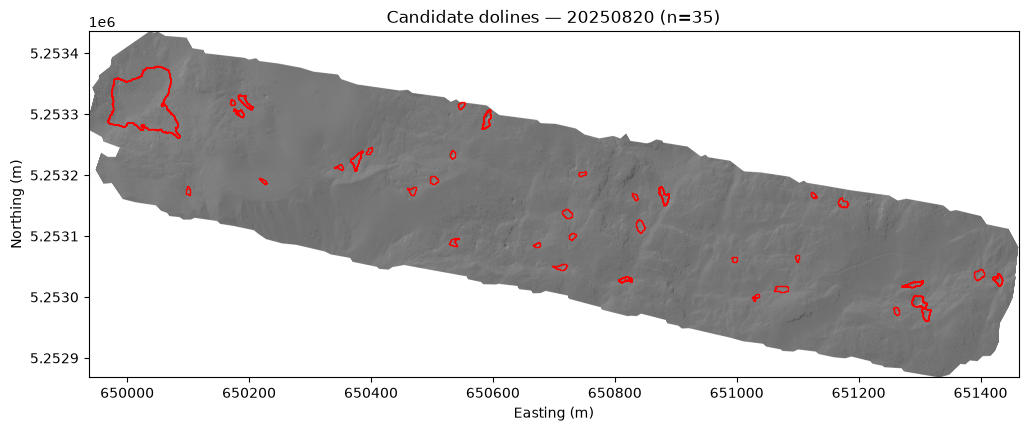

In [3]:
def hillshade(array: np.ndarray, azimuth: float = 315, angle_altitude: float = 45) -> np.ndarray:
    """Quick shaded-relief render for visual QC only, not a proper hillshade product."""
    dx, dy = np.gradient(array)
    slope = np.pi / 2 - np.arctan(np.sqrt(dx * dx + dy * dy))
    aspect = np.arctan2(-dx, dy)
    az, alt = np.radians(azimuth), np.radians(angle_altitude)
    shaded = np.sin(alt) * np.sin(slope) + np.cos(alt) * np.cos(slope) * np.cos(az - aspect)
    return (shaded + 1) / 2


with rasterio.open(clipped_dem) as src:
    dsm = src.read(1, masked=True).filled(np.nan)
    extent = rasterio.plot.plotting_extent(src)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(hillshade(dsm), cmap="gray", extent=extent)
dolines.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)
ax.set_title(f"Candidate dolines \u2014 {DATE} (n={len(dolines)})")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
fig.savefig(FIGURES / f"{DATE}_candidate_dolines.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
out_path = PROCESSED / f"{DATE}_candidate_dolines.gpkg"
dolines.to_file(out_path, driver="GPKG")
print(f"saved {len(dolines)} polygons to {out_path}")

saved 35 polygons to data\processed\20250820_candidate_dolines.gpkg
